# 00 - Simulate a waveform dataset

Generate a small flash dataset with the [`waveforms`](../../waveforms)
simulation package and save it in the format `flashdet` expects:
a pickled dict with `waveforms` (N, L), `arrival_times` (list per waveform),
and `num_photons` (list per waveform).

In [1]:
import sys
sys.path.append('/sdf/home/c/carsmith/flash_reconstruction/') 
sys.path.append('..')          # repo root, for `import flashdet`
sys.path.append('../..')       # for the sibling `waveforms` package

import numpy as np
import torch
import matplotlib.pyplot as plt

from waveforms.waveforms_module.make_waveform import BatchedLightSimulation

In [2]:
pwd

'/sdf/home/c/carsmith/flash_reconstruction/flash_detection/examples'

## Configure the simulator
Time parameters of the delay distributions are in microseconds; waveform-length
parameters are in nanoseconds. Keep the nominal optical constants fixed across
datasets so models see a consistent detector response.

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sim = BatchedLightSimulation(cfg='../../waveforms/templates/waveform_sim.yaml').to(device)

params = dict(
    light_tick_size=0.001,   # 100 ps, in microseconds
    downsample_factor=10,
    tpb_tau=0.002,           # us
    offset=0,                # ns
    n_ticks=80000,           # ns
    light_gain=-45.0,
    light_oscillation_period=0.11,
    light_response_time=0.055,
)
sim.reconfigure(params)
print(f'1 time tick = {sim.light_tick_size} microseconds')

BatchedLightSimulation Config:
	SINGLET_FRACTION: uniform(0.1, 0.5)
	LIGHT_OSCILLATION_PERIOD: uniform(0.05, 0.20)
	LIGHT_RESPONSE_TIME: uniform(0.01, 0.10)
	LIGHT_GAIN: uniform(-50.0, -20.0)
	TAU_S: uniform(0.0001, 0.01)
	TAU_T: uniform(0.9, 2.1)
	
	NOMINAL_SINGLET_FRACTION: 0.000000001 #0.35
	NOMINAL_LIGHT_OSCILLATION_PERIOD: 0.11     # us
	NOMINAL_LIGHT_RESPONSE_TIME: 0.055         # us^-1
	NOMINAL_TAU_S: 0.001                       # us
	NOMINAL_TAU_T: 1.530                       # us
	NOMINAL_LIGHT_GAIN: -45.0                  # ADC us/pe
	
	LIGHT_TICK_SIZE: 0.001                     # us
	LIGHT_WINDOW: [1, 10]
1 time tick = 0.001 microseconds


## Sanity check: a single-photon waveform
The rising edge should reach its peak within a few nanoseconds.

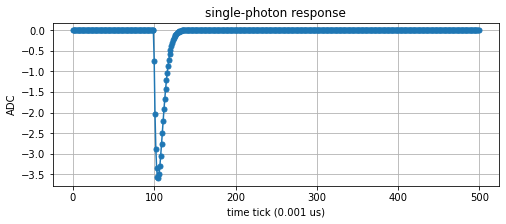

In [4]:
nphotons = 1
pmt_ids = torch.zeros(nphotons, dtype=torch.int64)
arrival_times = torch.zeros(nphotons, dtype=torch.int64) + 1000  # arrive at 100 ns
wf = sim.gen_waveform(mode='precise', pmt_ids=pmt_ids, arrival_times=arrival_times, n_pmts=1)

output, _ = sim(wf.to(device), scintillation=False, tpb_delay=False, combined=False)
output = output.detach().cpu().numpy()

plt.figure(figsize=(8, 3))
plt.plot(output[:500], marker='o', ms=5)
plt.xlabel(f'time tick ({sim.light_tick_size} us)')
plt.ylabel('ADC')
plt.title('single-photon response')
plt.grid(True); plt.show()

## Generate a small dataset
For each waveform we draw a number of flashes, and for each flash a photon
count and a start time, then sample scintillation + TPB re-emission delays per
photon. The full pipeline (used for the 200k-waveform training set) lives in
`archive/notebooks/simulating_data.ipynb`; here we make a tiny version.

In [5]:
PATH_TO_SAVE = 'demo_dataset.npy'
num_waveforms = 200
max_hits = 8

sim_waveforms, per_wf_arrival_times, per_wf_num_photons = [], [], []

for _ in range(num_waveforms):
    nhits = np.random.randint(2, max_hits + 1)
    ns = np.random.randint(10, 1001, size=nhits)          # photons per flash
    arrival = np.random.randint(50, 70001, size=nhits)    # start time (ticks)

    total = int(ns.sum())
    pmt_ids = torch.zeros(total, dtype=torch.int64)
    arrivals = torch.from_numpy(np.repeat(arrival, ns)).long()
    wf = sim.gen_waveform(mode='precise', pmt_ids=pmt_ids, arrival_times=arrivals, n_pmts=1)
    out, _ = sim(wf.to(device), scintillation=True, tpb_delay=True, combined=True)
    out = out.detach().cpu().numpy()
    out = out + np.random.normal(0, 4.8, size=out.shape)  # ~1-photon-amplitude noise

    sim_waveforms.append(out.astype(np.float32))
    per_wf_arrival_times.append((arrival / sim.downsample_factor).astype(int))
    per_wf_num_photons.append(ns)

dataset = {
    'waveforms': np.stack(sim_waveforms),
    'arrival_times': per_wf_arrival_times,
    'num_photons': per_wf_num_photons,
}
np.save(PATH_TO_SAVE, dataset, allow_pickle=True)
print('saved', PATH_TO_SAVE, '->', dataset['waveforms'].shape)

saved demo_dataset.npy -> (200, 8000)


## Inspect a waveform with its true flash times

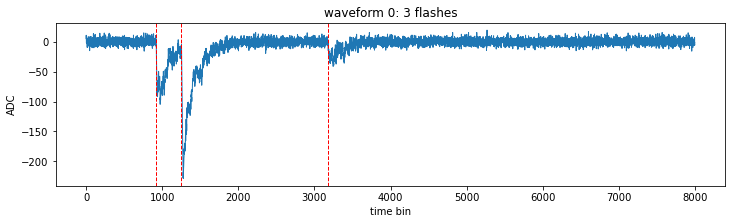

In [6]:
data = np.load(PATH_TO_SAVE, allow_pickle=True).item()
i = 0
wf = data['waveforms'][i]
plt.figure(figsize=(12, 3))
plt.plot(wf, lw=1)
for t in np.sort(data['arrival_times'][i]):
    plt.axvline(t, color='r', ls='--', lw=1)
plt.xlabel('time bin'); plt.ylabel('ADC')
plt.title(f'waveform {i}: {len(data["arrival_times"][i])} flashes')
plt.show()